# PCR-GLOBWB Discharge Analysis

Plot discharge data for all stations from PCR-GLOBWB calibration runs

In [1]:
import sys
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree



from src.constants import STATIONS_PCR

## Load NetCDF File

In [2]:
# Load NetCDF file
ncfile = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/outputs/model_runs/pcr-globwb/calibration_runs_overnight_13march_run1/run_237353b1/netcdf/discharge_dailyTot_output.nc"

print(f"Loading NetCDF file: {ncfile}")
ds = xr.open_dataset(ncfile)

print("Dataset variables:", list(ds.data_vars))
print("Dataset coordinates:", list(ds.coords))
print("\nDataset info:")
print(ds)

Loading NetCDF file: /home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/outputs/model_runs/pcr-globwb/calibration_runs_overnight_13march_run1/run_237353b1/netcdf/discharge_dailyTot_output.nc
Dataset variables: ['discharge']
Dataset coordinates: ['time', 'lat', 'lon']

Dataset info:
<xarray.Dataset> Size: 246MB
Dimensions:    (time: 1187, lat: 180, lon: 288)
Coordinates:
  * time       (time) datetime64[ns] 9kB 1948-10-01 1948-10-02 ... 1951-12-31
  * lat        (lat) float32 720B 47.96 47.88 47.79 47.71 ... 33.21 33.12 33.04
  * lon        (lon) float32 1kB 53.04 53.12 53.21 53.29 ... 76.79 76.88 76.96
Data variables:
    discharge  (time, lat, lon) float32 246MB ...
Attributes:
    institution:  Department of Physical Geography, Utrecht University
    title:        PCR-GLOBWB 2 output (not coupled to MODFLOW)
    description:  by Edwin H. Sutanudjaja (contact: e.h.sutanudjaja@uu.nl)


## Setup Spatial Indexing and Extract Discharge Data

In [3]:
# Extract latitude and longitude coordinates
lat = ds.coords["lat"].values
lon = ds.coords["lon"].values

# Create a grid of coordinates
lon_grid, lat_grid = np.meshgrid(lon, lat)
points = np.column_stack([lon_grid.ravel(), lat_grid.ravel()])

# Build a KD-tree for nearest neighbor search
tree = cKDTree(points)

# Get discharge variable
discharge_var = None
for var in ds.data_vars:
    if "discharge" in var.lower():
        discharge_var = var
        break

if discharge_var is None:
    print("Available variables:", list(ds.data_vars))
    raise ValueError("Could not find discharge variable in NetCDF file")

print(f"Using discharge variable: {discharge_var}")

Using discharge variable: discharge


## Plot Discharges for All Stations

Time range in filtered data: 1950-01-01T00:00:00.000000000 to 1950-12-31T00:00:00.000000000

Chatly:
  Requested: lat=42.2, lon=60.2
  Nearest grid cell: lat=42.20833206176758, lon=60.20833206176758
  Distance: 0.0118 degrees
  Mean discharge: 1479.75 m³/s, Max: 3644.29 m³/s

Kazalinsk:
  Requested: lat=45.7, lon=62.12
  Nearest grid cell: lat=45.70833206176758, lon=62.125
  Distance: 0.0097 degrees
  Mean discharge: 1539.01 m³/s, Max: 5855.32 m³/s

Kerki:
  Requested: lat=37.83, lon=65.3
  Nearest grid cell: lat=37.79166793823242, lon=65.29166412353516
  Distance: 0.0392 degrees
  Mean discharge: 778.37 m³/s, Max: 2256.00 m³/s

Tyumen-Aryk:
  Requested: lat=43.95, lon=67.05
  Nearest grid cell: lat=43.95833206176758, lon=67.04166412353516
  Distance: 0.0118 degrees
  Mean discharge: 1437.86 m³/s, Max: 5338.52 m³/s

Uch-Kurgan:
  Requested: lat=41.12, lon=72.1
  Nearest grid cell: lat=41.125, lon=72.125
  Distance: 0.0255 degrees
  Mean discharge: 237.04 m³/s, Max: 1436.82 m³/s

Garm:


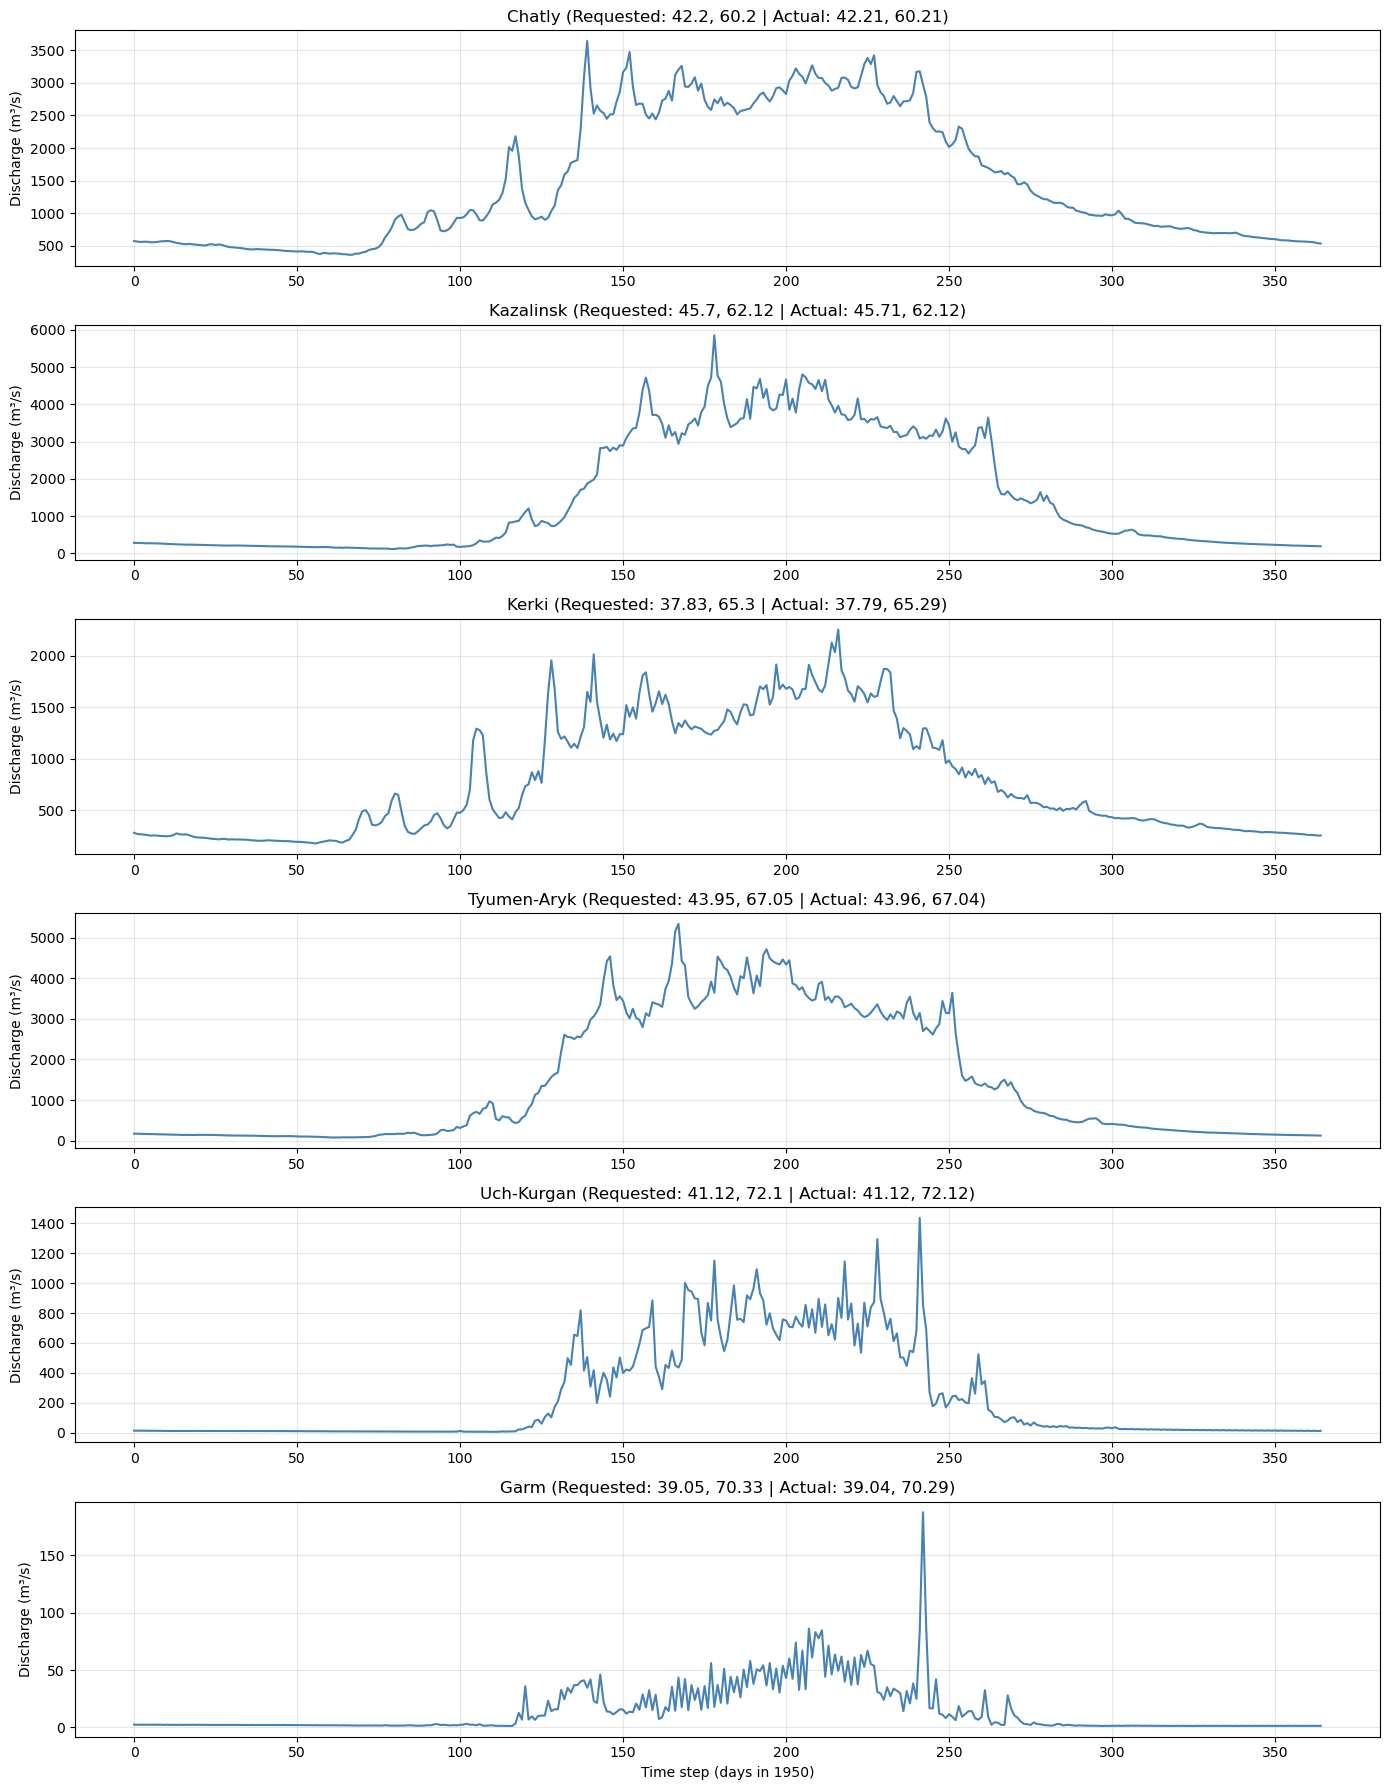


⚠️ Note: Tyumen-Aryk data should be verified for accuracy


In [4]:
# Filter data to only include year 1950
ds_1950 = ds.sel(time=slice("1950-01-01", "1950-12-31"))
print(f"Time range in filtered data: {ds_1950.time.values[0]} to {ds_1950.time.values[-1]}")

# Create figure
fig, axes = plt.subplots(len(STATIONS_PCR), 1, figsize=(14, 3 * len(STATIONS_PCR)))
if len(STATIONS_PCR) == 1:
    axes = [axes]

# Extract and plot data for each station
for idx, (station_name, station_info) in enumerate(STATIONS_PCR.items()):
    station_lat = station_info["lat"]
    station_lon = station_info["lon"]
    
    # Find nearest grid cell
    query_point = np.array([[station_lon, station_lat]])
    distance, location = tree.query(query_point)
    
    # Convert flat index to 2D indices
    nearest_idx = location[0]
    lat_idx, lon_idx = np.unravel_index(nearest_idx, lon_grid.shape)
    
    nearest_lat = lat[lat_idx]
    nearest_lon = lon[lon_idx]
    
    print(f"\n{station_name}:")
    print(f"  Requested: lat={station_lat}, lon={station_lon}")
    print(f"  Nearest grid cell: lat={nearest_lat}, lon={nearest_lon}")
    print(f"  Distance: {distance[0]:.4f} degrees")
    
    # Extract discharge for this location (1950 only)
    discharge = ds_1950[discharge_var].isel(lat=lat_idx, lon=lon_idx).values
    #discharge = ds_1950[discharge_var].sel(lat=station_lat, lon=station_lon).values
    print(f"  Mean discharge: {np.nanmean(discharge):.2f} m³/s, Max: {np.nanmax(discharge):.2f} m³/s")
    
    # Plot
    ax = axes[idx]
    ax.plot(discharge, linewidth=1.5, color='steelblue')
    ax.set_title(f"{station_name} (Requested: {station_lat}, {station_lon} | Actual: {nearest_lat:.2f}, {nearest_lon:.2f})")
    ax.set_ylabel("Discharge (m³/s)")
    ax.grid(True, alpha=0.3)
    if idx == len(STATIONS_PCR) - 1:
        ax.set_xlabel("Time step (days in 1950)")

plt.tight_layout()
plt.savefig("discharge_plot_1950.png", dpi=150, bbox_inches='tight')
print("\n\nPlot saved to: discharge_plot_1950.png")
plt.show()

print("\n⚠️ Note: Tyumen-Aryk data should be verified for accuracy")

ds.close()

## Spatial Map of Discharge at Timestep 200

Spatial map saved to: discharge_map_timestep200.png


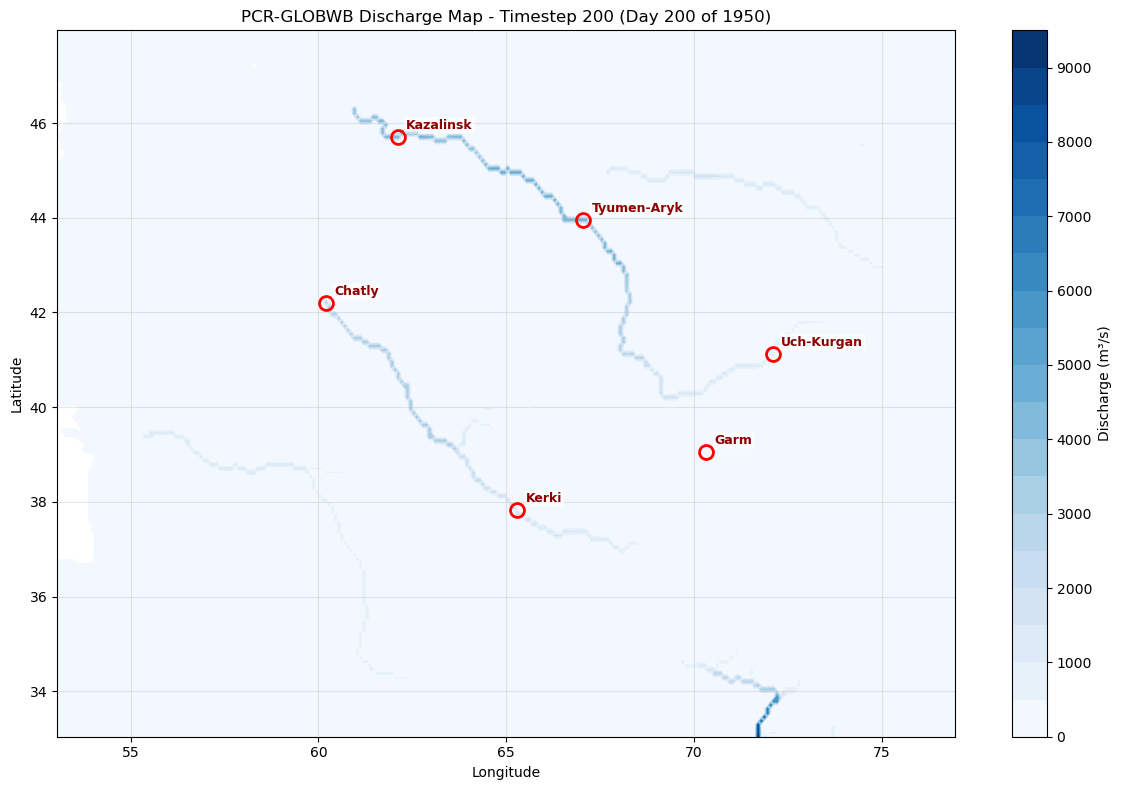


Timestep 200 date: 1950-07-19T00:00:00.000000000
Min discharge: 0.00 m³/s
Max discharge: 9155.48 m³/s
Mean discharge: 34.28 m³/s


In [5]:
# Get discharge at timestep 200
timestep = 199  # 0-indexed, so 199 = timestep 200
discharge_map = ds_1950[discharge_var].isel(time=timestep).values

# Create figure with map
fig, ax = plt.subplots(figsize=(12, 8))

# Plot discharge data
im = ax.contourf(lon, lat, discharge_map, levels=20, cmap='Blues')
cbar = plt.colorbar(im, ax=ax, label='Discharge (m³/s)')

# Add station markers and labels on the map
for station_name, station_info in STATIONS_PCR.items():
    station_lat = station_info["lat"]
    station_lon = station_info["lon"]
    ax.plot(
        station_lon,
        station_lat,
        marker='o',
        markersize=10,
        markeredgecolor='red',
        markerfacecolor='none',
        markeredgewidth=2,
    )
    ax.annotate(
        station_name,
        (station_lon, station_lat),
        xytext=(6, 6),
        textcoords='offset points',
        fontsize=9,
        color='darkred',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.65, edgecolor='none'),
    )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"PCR-GLOBWB Discharge Map - Timestep 200 (Day {timestep + 1} of 1950)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("discharge_map_timestep200.png", dpi=150, bbox_inches='tight')
print("Spatial map saved to: discharge_map_timestep200.png")
plt.show()

print(f"\nTimestep 200 date: {ds_1950.time.values[timestep]}")
print(f"Min discharge: {np.nanmin(discharge_map):.2f} m³/s")
print(f"Max discharge: {np.nanmax(discharge_map):.2f} m³/s")
print(f"Mean discharge: {np.nanmean(discharge_map):.2f} m³/s")

Region analysis saved to: station_region_analysis.png


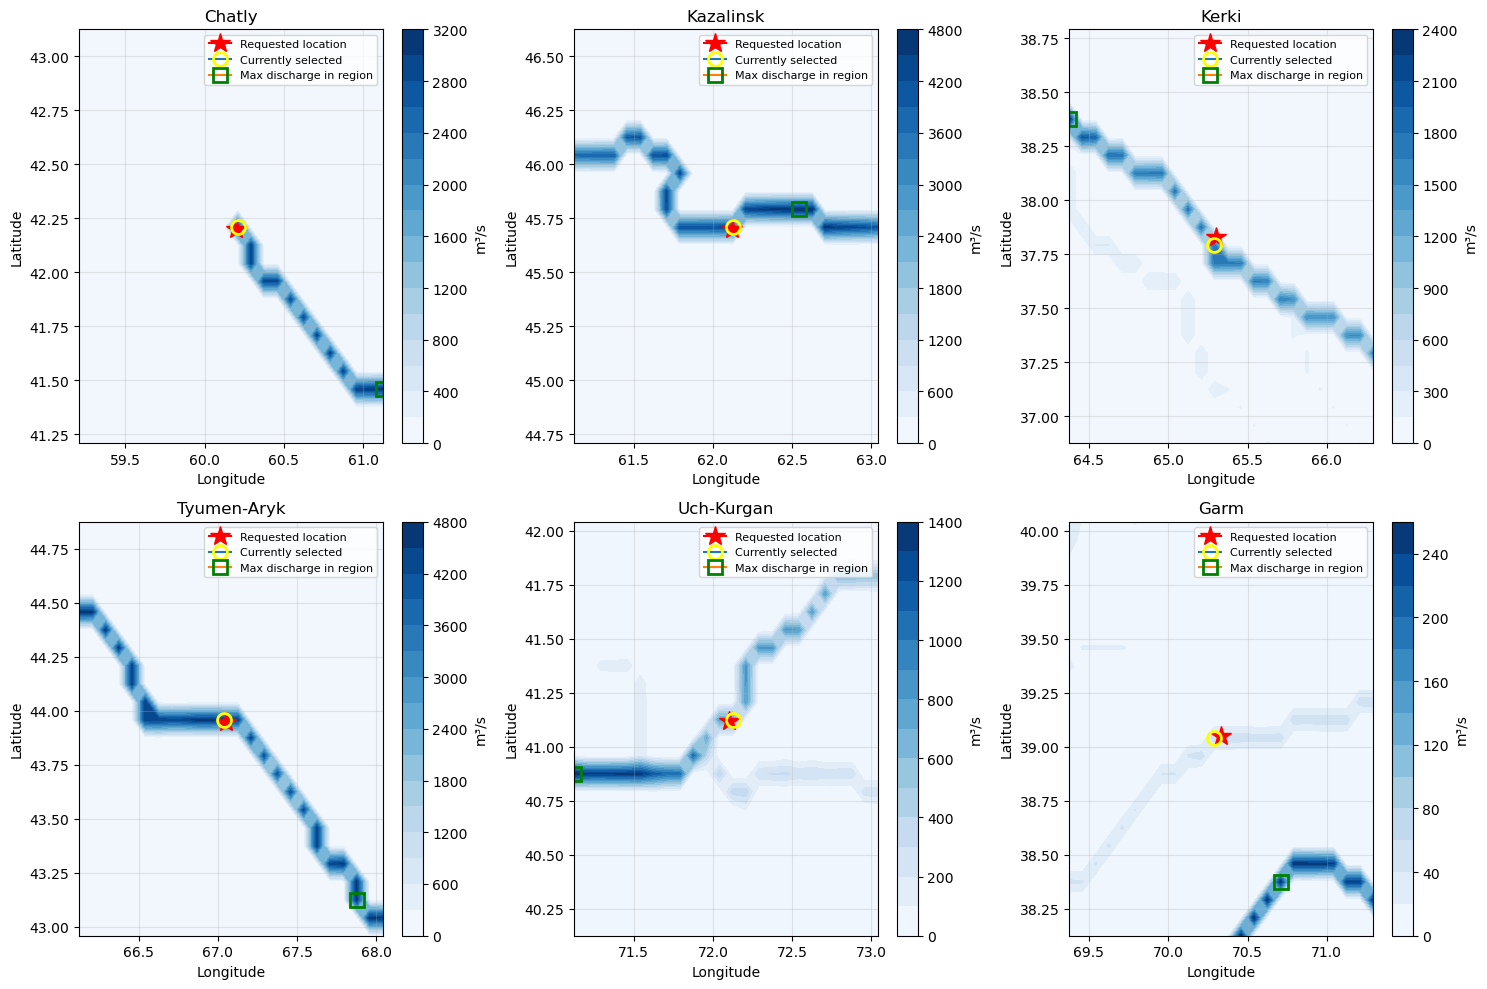


Analysis: Check which cells have higher discharge for each station
Red star = requested location
Yellow circle = currently selected cell (nearest neighbor)
Green square = max discharge cell in ±1 degree region


In [6]:
# Zoom in on each station to find best grid cell along river
import matplotlib.patches as patches

fig, axes_zoom = plt.subplots(2, 3, figsize=(15, 10))
axes_zoom = axes_zoom.flatten()

for idx, (station_name, station_info) in enumerate(STATIONS_PCR.items()):
    station_lat = station_info["lat"]
    station_lon = station_info["lon"]
    
    # Create a zoomed region (±1 degree)
    lat_min, lat_max = station_lat - 1, station_lat + 1
    lon_min, lon_max = station_lon - 1, station_lon + 1
    
    # Slice the data using isel for time and sel for spatial
    discharge_zoom = ds_1950[discharge_var].isel(time=timestep).sel(
        lat=slice(lat_max, lat_min), 
        lon=slice(lon_min, lon_max)
    ).values
    
    lat_zoom = ds_1950.lat.sel(lat=slice(lat_max, lat_min)).values
    lon_zoom = ds_1950.lon.sel(lon=slice(lon_min, lon_max)).values
    
    # Plot
    ax = axes_zoom[idx]
    im = ax.contourf(lon_zoom, lat_zoom, discharge_zoom, levels=15, cmap='Blues')
    plt.colorbar(im, ax=ax, label='m³/s')
    
    # Mark the requested station
    ax.plot(station_lon, station_lat, marker='*', markersize=15, 
            color='red', label='Requested location')
    
    # Find and mark the current nearest grid cell
    query_point = np.array([[station_lon, station_lat]])
    distance, location = tree.query(query_point)
    nearest_idx = location[0]
    lat_idx, lon_idx = np.unravel_index(nearest_idx, lon_grid.shape)
    nearest_lat = lat[lat_idx]
    nearest_lon = lon[lon_idx]
    
    ax.plot(nearest_lon, nearest_lat, marker='o', markersize=10, 
            markeredgecolor='yellow', markerfacecolor='none', markeredgewidth=2,
            label='Currently selected')
    
    # Find max discharge cell in this region
    max_idx = np.nanargmax(discharge_zoom)
    lat_max_idx, lon_max_idx = np.unravel_index(max_idx, discharge_zoom.shape)
    lat_max_cell = lat_zoom[lat_max_idx]
    lon_max_cell = lon_zoom[lon_max_idx]
    
    ax.plot(lon_max_cell, lat_max_cell, marker='s', markersize=10, 
            markeredgecolor='green', markerfacecolor='none', markeredgewidth=2,
            label='Max discharge in region')
    
    ax.set_title(f"{station_name}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Hide the extra subplot
# axes_zoom[5].set_visible(False)

plt.tight_layout()
plt.savefig("station_region_analysis.png", dpi=150, bbox_inches='tight')
print("Region analysis saved to: station_region_analysis.png")
plt.show()

print("\nAnalysis: Check which cells have higher discharge for each station")
print("Red star = requested location")
print("Yellow circle = currently selected cell (nearest neighbor)")
print("Green square = max discharge cell in ±1 degree region")

In [7]:
from pathlib import Path
import glob

# Define the base path for calibration runs
#base_path = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/outputs/model_runs/pcr-globwb/calibration_runs_11march_overnight"
base_path = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/outputs/model_runs/pcr-globwb/calibration_runs_overnight_14march_run1"
# Find all run directories
run_dirs = sorted([d for d in Path(base_path).glob("run_*") if d.is_dir()])
run_dirs = [d for d in run_dirs if d.name != "run_0007"]  # Exclude run_0007

print(f"Found {len(run_dirs)} runs (excluding run_0007):")
for run_dir in run_dirs:
    print(f"  {run_dir.name}")

# Load discharge data from each run
discharge_data = {}
for run_dir in run_dirs:
    ncfile = run_dir / "netcdf" / "discharge_dailyTot_output.nc"
    if ncfile.exists():
        try:
            ds_run = xr.open_dataset(ncfile)
            discharge_data[run_dir.name] = ds_run
            print(f"✓ Loaded {run_dir.name}")
        except Exception as e:
            print(f"✗ Error loading {run_dir.name}: {e}")
    else:
        print(f"✗ NetCDF file not found: {ncfile}")

print(f"\nSuccessfully loaded {len(discharge_data)} runs")

Found 72 runs (excluding run_0007):
  run_00837e67
  run_02de885e
  run_067f81b5
  run_06e29db7
  run_0a48b17e
  run_0a49bc75
  run_112112e9
  run_152e3788
  run_16971adf
  run_19956118
  run_1a03b9a7
  run_1a0a3b5c
  run_20b4cc23
  run_24db6286
  run_2c4451fc
  run_2c6d93c2
  run_2da1906a
  run_326ed5be
  run_37d018a3
  run_3bbcc8b5
  run_444742de
  run_464fd2ff
  run_50e35da4
  run_5cb6044a
  run_5dc60d35
  run_66abc1f3
  run_691eadaa
  run_6daa26fe
  run_6db32f1d
  run_702b07e0
  run_720197d7
  run_744cb8c6
  run_753c3cf9
  run_8138026d
  run_8605832c
  run_8640ba3b
  run_880695d1
  run_935ad1a6
  run_968e6024
  run_9cc774ef
  run_9d4fee96
  run_a349fcc3
  run_a7b751f0
  run_a8ecb893
  run_a9df1929
  run_ad677ef4
  run_ae31436f
  run_b2b72df6
  run_b2e64f53
  run_b7de96e8
  run_bc9e84a7
  run_c1722dcd
  run_c3ef9300
  run_c71009a4
  run_cc3797db
  run_ccb3a50f
  run_cecee492
  run_d4aed634
  run_d528b188
  run_d90a0a1f
  run_d90bd6cd
  run_df38045d
  run_dfc9ff4d
  run_e960c4be
  ru

In [8]:
# Extract discharge for each station across all runs (1950-1951 data)
print("Extracting discharge for each station across all runs (1950-1951 only):\n")

# Store discharge time series for each station and run
station_discharge_by_run = {station: {} for station in STATIONS_PCR.keys()}

for run_name, ds_run in discharge_data.items():
    ds_run_1950 = ds_run.sel(time=slice("1950-01-01", "1951-12-31"))
    
    for station_name, station_info in STATIONS_PCR.items():
        station_lat = station_info["lat"]
        station_lon = station_info["lon"]
        
        # Find nearest grid cell
        query_point = np.array([[station_lon, station_lat]])
        distance, location = tree.query(query_point)
        nearest_idx = location[0]
        lat_idx, lon_idx = np.unravel_index(nearest_idx, lon_grid.shape)
        
        # Extract discharge for this location
        discharge = ds_run_1950[discharge_var].isel(lat=lat_idx, lon=lon_idx).values
        station_discharge_by_run[station_name][run_name] = discharge

print("Data extracted successfully")


Extracting discharge for each station across all runs (1950-1951 only):

Data extracted successfully



Comparison plot saved to: discharge_comparison_all_runs.png


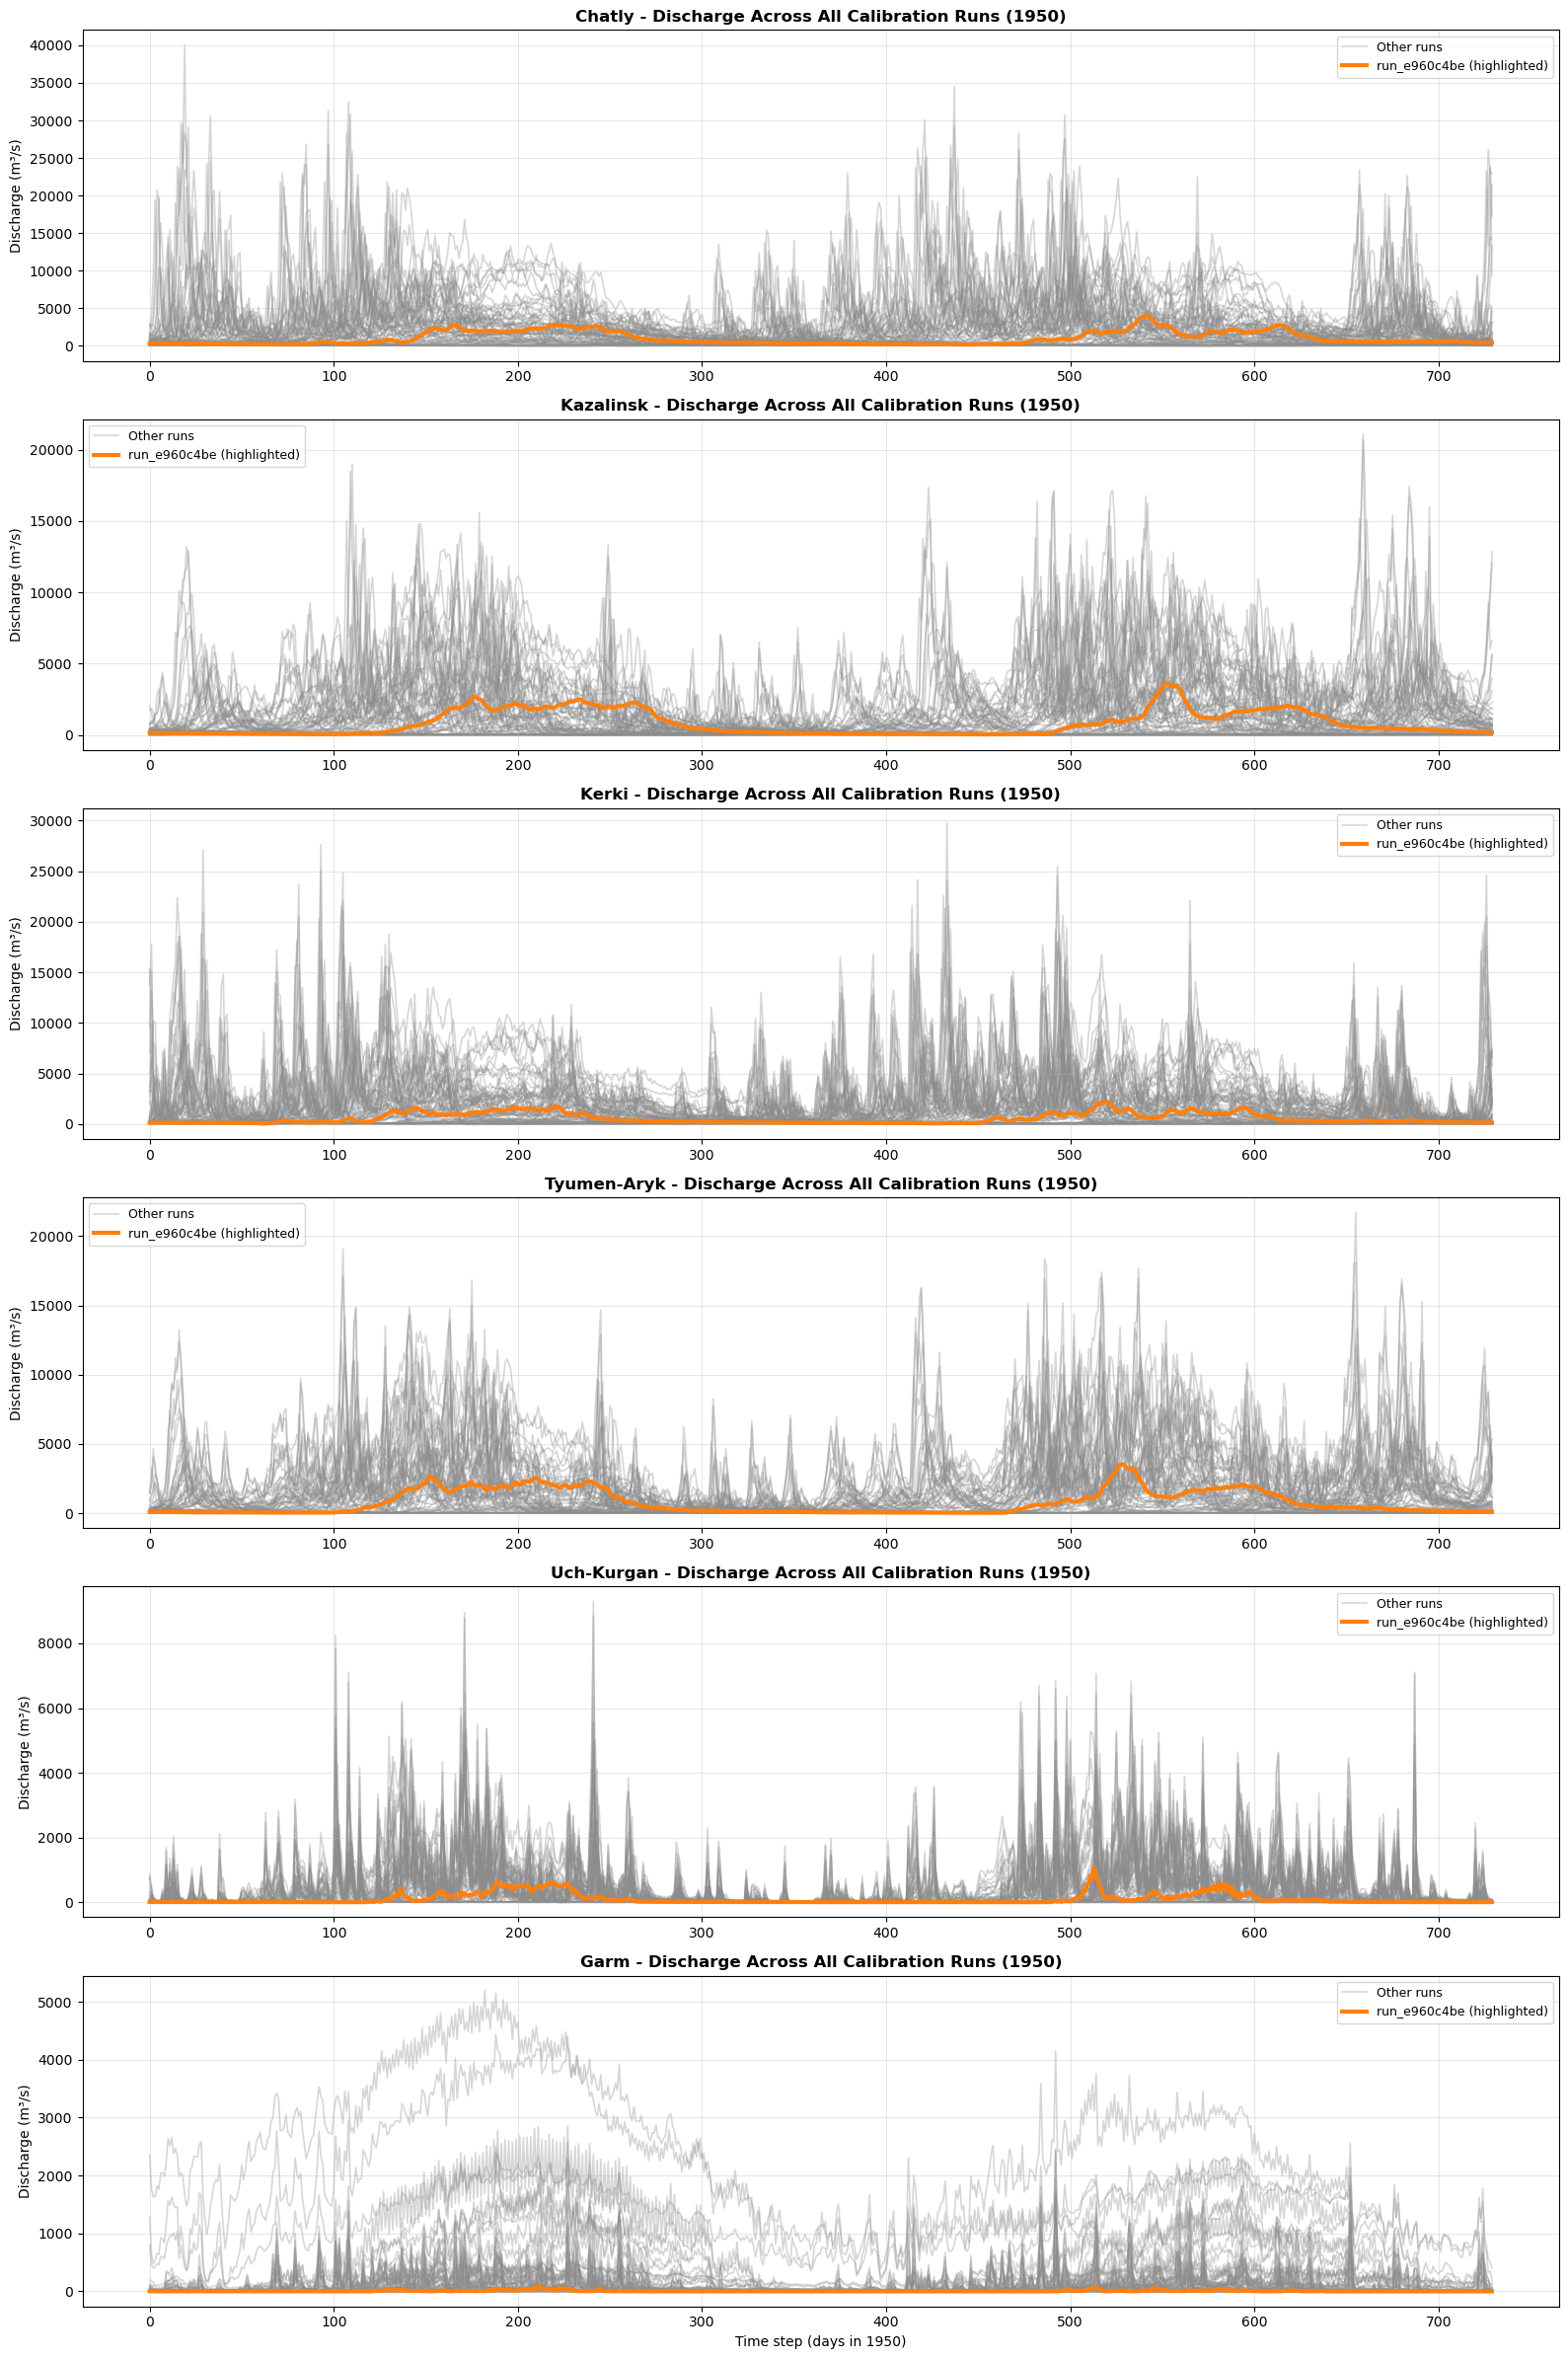


SUMMARY STATISTICS FOR EACH STATION ACROSS ALL RUNS

Chatly:
Run          Mean (m³/s)        Max (m³/s)         Min (m³/s)        
----------------------------------------------------------------------
run_00837e67            43.93           162.26             5.44
run_02de885e          1175.66          6226.50           270.15
run_067f81b5          4124.41         13651.38           649.89
run_06e29db7          6876.64         30825.38           714.32
run_0a48b17e          4564.14         29475.72           167.37
run_0a49bc75           323.45          1043.96            61.21
run_112112e9           208.80           519.31            70.70
run_152e3788          2272.18          9657.93           267.64
run_16971adf            21.33            56.43             0.00
run_19956118          2238.12          7079.44           505.21
run_1a03b9a7            63.27           205.67             6.82
run_1a0a3b5c          2234.50          9573.98           178.85
run_20b4cc23          2076.29

In [9]:
# Plot discharge for each station across all runs
fig, axes_multi = plt.subplots(len(STATIONS_PCR), 1, figsize=(16, 4 * len(STATIONS_PCR)))
if len(STATIONS_PCR) == 1:
    axes_multi = [axes_multi]

colors = plt.cm.tab10(np.linspace(0, 1, len(discharge_data)))
run_names = sorted(discharge_data.keys())

highlight_run = "run_e960c4be"
highlight_run_id = highlight_run.removeprefix("run_")

for station_idx, (station_name, discharge_by_run) in enumerate(station_discharge_by_run.items()):
    ax = axes_multi[station_idx]

    # Plot each run, emphasizing one selected run
    added_other_label = False
    highlight_found = False

    for run_idx, run_name in enumerate(run_names):
        if run_name in discharge_by_run:
            discharge = discharge_by_run[run_name]
            is_highlighted = run_name in {highlight_run, highlight_run_id, f"run_{highlight_run_id}"}

            if is_highlighted:
                highlight_found = True
                ax.plot(
                    discharge,
                    linewidth=3,
                    label=f"{run_name} (highlighted)",
                    color="tab:orange",
                    alpha=1.0,
                    zorder=5,
                )
            else:
                label = "Other runs" if not added_other_label else "_nolegend_"
                ax.plot(
                    discharge,
                    linewidth=1.2,
                    label=label,
                    color="0.55",
                    alpha=0.35,
                    zorder=1,
                )
                added_other_label = True

    if not highlight_found:
        ax.text(
            0.02,
            0.92,
            f"Highlighted run '{highlight_run}' not found",
            transform=ax.transAxes,
            fontsize=9,
            color="tab:red",
            va="top",
        )

    ax.set_title(f"{station_name} - Discharge Across All Calibration Runs (1950)", fontsize=12, fontweight='bold')
    ax.set_ylabel("Discharge (m³/s)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9)
    if station_idx == len(STATIONS_PCR) - 1:
        ax.set_xlabel("Time step (days in 1950)")

plt.tight_layout()
plt.savefig("discharge_comparison_all_runs.png", dpi=150, bbox_inches='tight')
print("\nComparison plot saved to: discharge_comparison_all_runs.png")
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS FOR EACH STATION ACROSS ALL RUNS")
print("="*80)
for station_name, discharge_by_run in station_discharge_by_run.items():
    print(f"\n{station_name}:")
    print(f"{'Run':<12} {'Mean (m³/s)':<18} {'Max (m³/s)':<18} {'Min (m³/s)':<18}")
    print("-" * 70)
    for run_name in run_names:
        if run_name in discharge_by_run:
            discharge = discharge_by_run[run_name]
            print(f"{run_name:<12} {np.nanmean(discharge):>16.2f} {np.nanmax(discharge):>16.2f} {np.nanmin(discharge):>16.2f}")

## Load GRDC Observational Data for Chatly

In [10]:
import ewatercycle.observation.grdc
from pathlib import Path
import pandas as pd

# Define GRDC data directory
from src.paths import GRDC

# Define calibration period (1950 year from the model)
cal_start = "1949-10-01T00:00:00Z"
cal_end = "1951-12-31T00:00:00Z"

# Load GRDC observation data for Chatly (station ID: 2817100)
print("Loading GRDC observation data for Chatly...")
print(f"Date range: {cal_start} to {cal_end}")

try:
    obs_data_chatly = ewatercycle.observation.grdc.get_grdc_data(
        data_home=GRDC / "Daily",
        station_id="2817100",
        start_time=cal_start,
        end_time=cal_end,
    )
    print(f"✓ Successfully loaded Chatly GRDC data")
    print(f"  Type: {type(obs_data_chatly)}")
    
    # Handle different return types
    if isinstance(obs_data_chatly, dict):
        print(f"  Keys: {obs_data_chatly.keys()}")
        print(f"  Time range: {obs_data_chatly['time'][0]} to {obs_data_chatly['time'][-1]}")
        print(f"  Number of days: {len(obs_data_chatly['time'])}")
        print(f"  Streamflow stats - Mean: {np.mean(obs_data_chatly['streamflow']):.2f}, Max: {np.max(obs_data_chatly['streamflow']):.2f}")
    else:
        # Assume xarray Dataset
        print(f"  Dimensions: {obs_data_chatly.dims}")
        print(f"  Data variables: {list(obs_data_chatly.data_vars)}")
        print(f"  Time range: {obs_data_chatly.time.values[0]} to {obs_data_chatly.time.values[-1]}")
        
        # Find streamflow/discharge variable
        streamflow_var = None
        for var in obs_data_chatly.data_vars:
            if 'streamflow' in var.lower() or 'discharge' in var.lower() or 'q' == var.lower():
                streamflow_var = var
                break
        
        if streamflow_var:
            obs_values = obs_data_chatly[streamflow_var].values
            print(f"  Streamflow variable: '{streamflow_var}' with shape {obs_values.shape}")
            print(f"  Streamflow stats - Mean: {np.nanmean(obs_values):.2f}, Max: {np.nanmax(obs_values):.2f}")
        else:
            print(f"  Available variables: {list(obs_data_chatly.data_vars)}")
        
except Exception as e:
    print(f"✗ Error loading GRDC data: {e}")
    import traceback
    traceback.print_exc()
    obs_data_chatly = None

Loading GRDC observation data for Chatly...
Date range: 1949-10-01T00:00:00Z to 1951-12-31T00:00:00Z
✓ Successfully loaded Chatly GRDC data
  Type: <class 'xarray.core.dataset.Dataset'>
  Dimensions: FrozenMappingWarningOnValuesAccess({'time': 822})
  Data variables: ['streamflow', 'area', 'country', 'geo_x', 'geo_y', 'geo_z', 'owneroforiginaldata', 'river_name', 'station_name', 'timezone']
  Time range: 1949-10-01T00:00:00.000000000 to 1951-12-31T00:00:00.000000000
  Streamflow variable: 'streamflow' with shape (822,)
  Streamflow stats - Mean: 1164.07, Max: 3430.00


In [11]:
STATIONS_GRDC = {
    "Chatly":   "2817100",
    "Tyumen-Aryk": "2316200",
    "Garm" : "2517920",
    "Uch-Kurgan": "2416850",
}



Loading GRDC data for Chatly (2817100)...
  Observation stats (1950-1951): mean=1182.61, max=3430.00, min=157.00 m3/s

Loading GRDC data for Tyumen-Aryk (2316200)...
  Observation stats (1950-1951): mean=554.28, max=1840.00, min=168.00 m3/s

Loading GRDC data for Garm (2517920)...
  Observation stats (1950-1951): mean=302.61, max=1210.00, min=92.00 m3/s

Loading GRDC data for Uch-Kurgan (2416850)...
  Observation stats (1950-1951): mean=360.68, max=1720.00, min=131.00 m3/s

Comparison plot saved to: grdc_obs_vs_model_all_stations_1950_1951.png


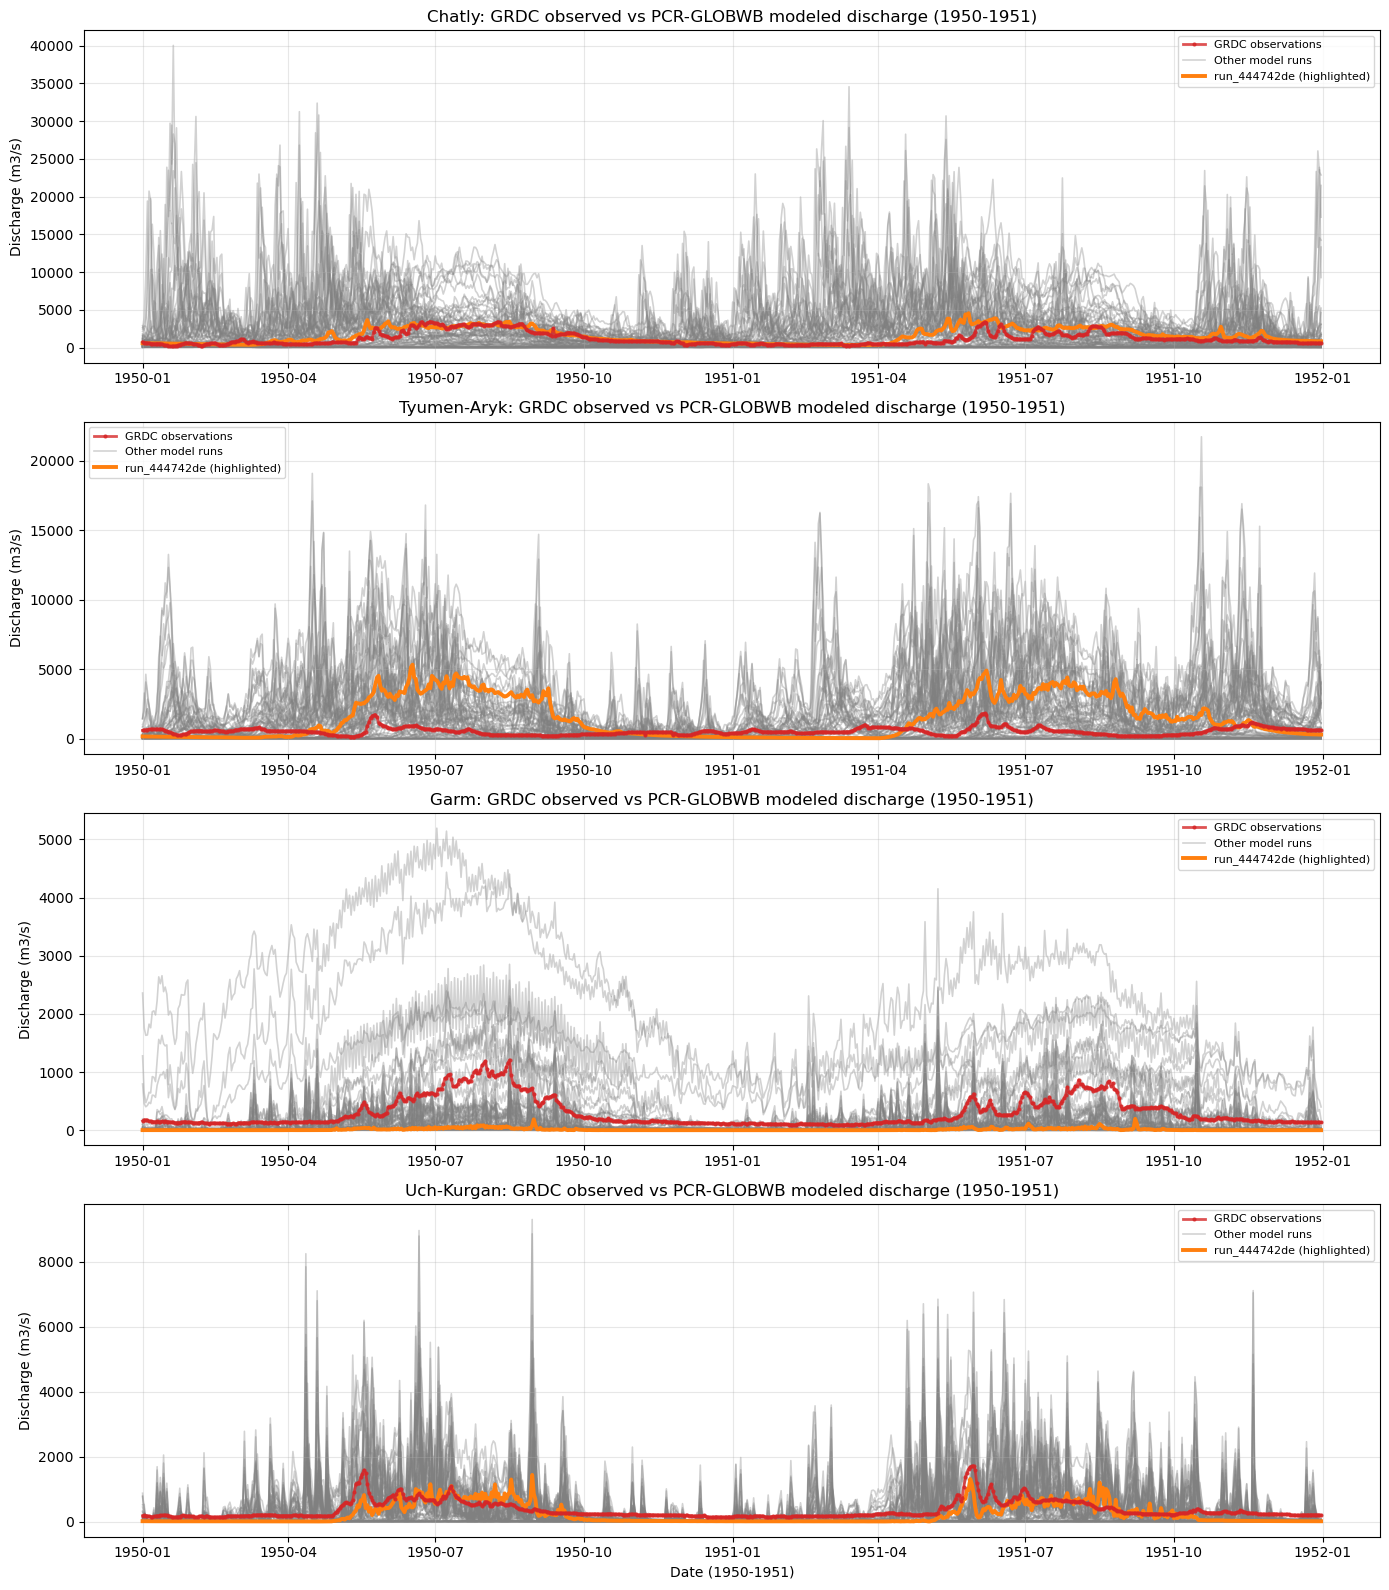

In [12]:
# Compare modeled discharge with observed GRDC data for all stations in STATIONS_GRDC
import ewatercycle.observation.grdc
import pandas as pd

# Define calibration period (model year 1950)
cal_start = "1949-10-01T00:00:00Z"
cal_end = "1951-12-31T00:00:00Z"

run_names_sorted = sorted(discharge_data.keys())
colors = plt.cm.tab10(np.linspace(0, 1, len(run_names_sorted)))

highlight_run = "run_444742de"
highlight_run_id = highlight_run.removeprefix("run_")

# Reference time axis covering 1950-1951 from first available run
time_axis_ref = next(iter(discharge_data.values())).sel(time=slice("1950-01-01", "1951-12-31")).time.values

fig, axes = plt.subplots(len(STATIONS_GRDC), 1, figsize=(14, 4 * len(STATIONS_GRDC)), sharex=False)
if len(STATIONS_GRDC) == 1:
    axes = [axes]

for idx, (station_name, station_id) in enumerate(STATIONS_GRDC.items()):
    ax = axes[idx]
    print(f"\nLoading GRDC data for {station_name} ({station_id})...")

    try:
        obs_data = ewatercycle.observation.grdc.get_grdc_data(
            data_home=GRDC / "Daily",
            station_id=station_id,
            start_time=cal_start,
            end_time=cal_end,
        )

        # Handle different GRDC return types and keep only 1950-1951
        if isinstance(obs_data, dict):
            obs_time = pd.to_datetime(obs_data["time"])
            obs_streamflow = np.asarray(obs_data["streamflow"], dtype=float)
            mask_1950 = (obs_time >= pd.Timestamp("1950-01-01")) & (obs_time <= pd.Timestamp("1951-12-31"))
            obs_time = obs_time[mask_1950]
            obs_streamflow = obs_streamflow[mask_1950]
        else:
            obs_data_1950 = obs_data.sel(time=slice("1950-01-01", "1951-12-31"))
            obs_time = obs_data_1950.time.values

            streamflow_var = None
            for var in obs_data_1950.data_vars:
                if "streamflow" in var.lower() or "discharge" in var.lower() or var.lower() == "q":
                    streamflow_var = var
                    break

            if streamflow_var is None:
                raise ValueError(f"Could not find streamflow variable in {list(obs_data_1950.data_vars)}")

            obs_streamflow = obs_data_1950[streamflow_var].values

        if len(obs_streamflow) == 0:
            raise ValueError("No GRDC values found in 1950-1951")

        # Plot observations
        ax.plot(
            obs_time,
            obs_streamflow,
            linewidth=2,
            label="GRDC observations",
            color="tab:red",
            marker="o",
            markersize=2,
            alpha=0.8,
            zorder=5,
        )

        # Plot model runs for matching station name
        if station_name in station_discharge_by_run:
            added_other_label = False
            highlight_found = False

            for run_idx, run_name in enumerate(run_names_sorted):
                if run_name in station_discharge_by_run[station_name]:
                    modeled_discharge = station_discharge_by_run[station_name][run_name]
                    time_axis = time_axis_ref[:len(modeled_discharge)]
                    is_highlighted = run_name in {highlight_run, highlight_run_id, f"run_{highlight_run_id}"}

                    if is_highlighted:
                        highlight_found = True
                        ax.plot(
                            time_axis,
                            modeled_discharge,
                            linewidth=2.8,
                            label=f"{run_name} (highlighted)",
                            color="tab:orange",
                            alpha=1.0,
                            zorder=4,
                        )
                    else:
                        label = "Other model runs" if not added_other_label else "_nolegend_"
                        ax.plot(
                            time_axis,
                            modeled_discharge,
                            linewidth=1.2,
                            label=label,
                            color="0.5",
                            alpha=0.35,
                            zorder=1,
                        )
                        added_other_label = True

            if not highlight_found:
                ax.text(
                    0.02,
                    0.92,
                    f"Highlighted run '{highlight_run}' not found",
                    transform=ax.transAxes,
                    fontsize=9,
                    color="tab:red",
                    va="top",
                )
        else:
            ax.text(
                0.5,
                0.5,
                f"No modeled station found for '{station_name}'",
                transform=ax.transAxes,
                ha="center",
                va="center",
                color="red",
            )

        ax.set_title(f"{station_name}: GRDC observed vs PCR-GLOBWB modeled discharge (1950-1951)")
        ax.set_ylabel("Discharge (m3/s)")
        ax.grid(True, alpha=0.3)
        ax.legend(loc="best", fontsize=8)

        print(
            f"  Observation stats (1950-1951): mean={np.nanmean(obs_streamflow):.2f}, "
            f"max={np.nanmax(obs_streamflow):.2f}, min={np.nanmin(obs_streamflow):.2f} m3/s"
        )

    except Exception as e:
        ax.set_title(f"{station_name}: ERROR loading/plotting data")
        ax.text(0.5, 0.5, str(e), transform=ax.transAxes, ha="center", va="center", color="red")
        ax.grid(True, alpha=0.3)
        print(f"  Error: {e}")

axes[-1].set_xlabel("Date (1950-1951)")
plt.tight_layout()
plt.savefig("grdc_obs_vs_model_all_stations_1950_1951.png", dpi=150, bbox_inches="tight")
print("\nComparison plot saved to: grdc_obs_vs_model_all_stations_1950_1951.png")
plt.show()


✓ Chatly: mean=1306.3, max=3430.0 m³/s
✓ Tyumen-Aryk: mean=506.9, max=1740.0 m³/s
✓ Garm: mean=334.4, max=1210.0 m³/s
✓ Uch-Kurgan: mean=355.3, max=1590.0 m³/s

Plot saved to: grdc_all_stations_1950.png


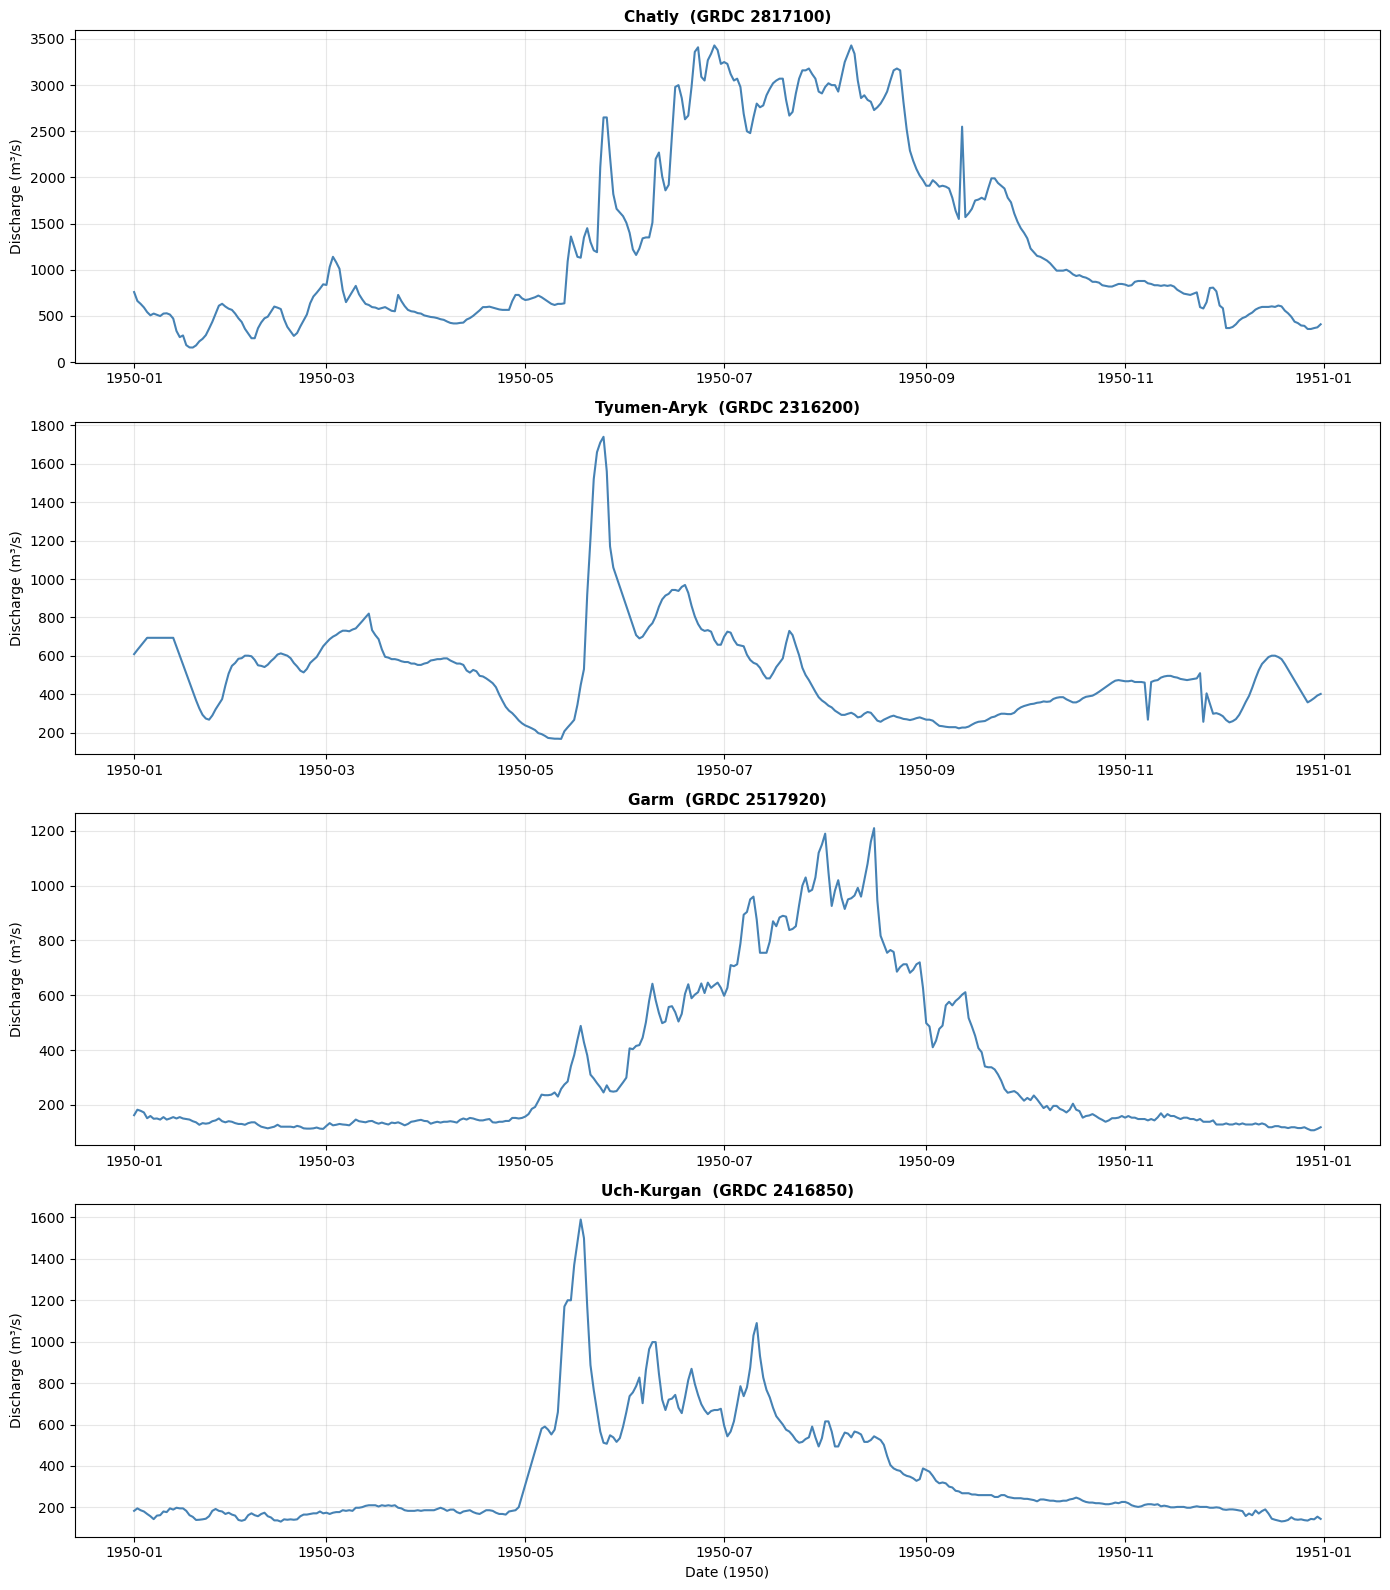

In [13]:

# Load and plot GRDC observations for all stations (1950)
import ewatercycle.observation.grdc
from src.paths import GRDC

cal_start = "1949-10-01T00:00:00Z"
cal_end   = "1950-12-31T00:00:00Z"

fig, axes = plt.subplots(len(STATIONS_GRDC), 1, figsize=(14, 4 * len(STATIONS_GRDC)), sharex=False)
if len(STATIONS_GRDC) == 1:
    axes = [axes]

for idx, (station_name, station_id) in enumerate(STATIONS_GRDC.items()):
    ax = axes[idx]
    try:
        obs = ewatercycle.observation.grdc.get_grdc_data(
            data_home=GRDC / "Daily",
            station_id=station_id,
            start_time=cal_start,
            end_time=cal_end,
        )

        # Filter to 1950
        if isinstance(obs, dict):
            time_vals = obs["time"]
            q_vals    = obs["streamflow"]
        else:
            obs_1950 = obs.sel(time=slice("1950-01-01", "1950-12-31"))
            time_vals = obs_1950.time.values
            q_var = next(
                (v for v in obs_1950.data_vars
                 if any(k in v.lower() for k in ("streamflow", "discharge", "q"))),
                None,
            )
            if q_var is None:
                raise ValueError(f"No discharge variable found; available: {list(obs_1950.data_vars)}")
            q_vals = obs_1950[q_var].values

        ax.plot(time_vals, q_vals, linewidth=1.5, color="steelblue")
        ax.set_title(f"{station_name}  (GRDC {station_id})", fontsize=11, fontweight="bold")
        ax.set_ylabel("Discharge (m³/s)")
        ax.grid(True, alpha=0.3)
        print(f"✓ {station_name}: mean={float(np.nanmean(q_vals)):.1f}, max={float(np.nanmax(q_vals)):.1f} m³/s")

    except Exception as e:
        ax.set_title(f"{station_name}  (GRDC {station_id}) — ERROR", fontsize=11)
        ax.text(0.5, 0.5, str(e), transform=ax.transAxes, ha="center", va="center", color="red")
        print(f"✗ {station_name}: {e}")

axes[-1].set_xlabel("Date (1950)")
plt.tight_layout()
plt.savefig("grdc_all_stations_1950.png", dpi=150, bbox_inches="tight")
print("\nPlot saved to: grdc_all_stations_1950.png")
plt.show()
